In [17]:
import uproot
import pandas as pd
import numpy as np
import awkward as ak
import os
import json
import ROOT

In [18]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import matplotlib.lines as lines
from matplotlib.collections import PatchCollection
plt.rcParams.update({'font.size': 15})

In [19]:
os.environ['ttH_yy_DIR'] = '/eos/user/e/elmazzeo/ttH@FCC-hh/results/2025-03-06_new/'

In [20]:
basedir = os.path.join(os.environ.get('ttH_yy_DIR'), 'final')
outdir = os.path.join(os.environ.get('ttH_yy_DIR'), 'plots')
color_sequence = ["#3f90da","#ffa90e","#bd1f01","#94a4a2","#832db6","#a96b59","#e76300","#b9ac70","#717581","#92dadd"]
process = {
    'ttHyy' : { 'sample_list' : ['mgp8_pp_tth01j_5f_haa'], 
               'label' : r'$ttH \rightarrow \gamma\gamma$',
               'color' : color_sequence[0]}
}


selection = {
    'nocuts' : "All events"
}

process_infos = ["/eos/experiment/fcc/hh/utils/FCCDicts/FCChh_procDict_fcc_v07_II.json",
                 "/eos/experiment/fcc/hh/utils/FCCDicts/FCChh_procDict_fcc_v06_II.json"]

lumi = 3e7 # 3 * 10^7 pb-1 = 3 ab-1

In [21]:
if os.path.isdir(outdir) :
    pass
else :
    os.makedirs(outdir)

In [22]:
def error_boxes (ax,x,y,x_err,y_err,fc='lightgrey',ec='None',alpha=0.5, hatch=None):

    # Create list for all the error patches
    errorboxes = []

    # Loop over data points; create box from errors at each point
    for xc,yc,xe,ye in zip(x,y,x_err.T,y_err.T):
        rect = patches.Rectangle((xc-xe,yc-ye),2*xe,2*ye)
        errorboxes.append(rect)

    # Create patch collection with specified colour/alpha
    pc = PatchCollection(errorboxes,facecolor=fc,alpha=alpha,edgecolor=ec, hatch=hatch)

    # Add collection to axes
    ax.add_collection(pc)

In [23]:
process_dicts = []
for inputname in process_infos :
    with open(inputname, 'r') as f :
        process_dicts.append(json.load(f))

In [24]:
from importlib import import_module
import sys
sys.path.insert(1, "../")

In [25]:
# ok now I want to plot b-jets and photons variables
selection = {
    "nocuts" : "All events",
}
analysis_final = import_module("analysis_final")
variables_dict = analysis_final.histoList

In [26]:
variables_list = [
            # reco photons from Higgs
            'n_higgs', 'E_higgs', 'pT_higgs', 'eta_higgs', 'phi_higgs', 'rapidity_higgs', 
            'higgs_decay_type', 'higgs_child1_pdgId', 'higgs_child2_pdgId',
            'weight'
]

In [27]:
df = {}
sow = {}

In [28]:
for p in process.keys() :
    df[p] = {}
    print(p)
    for s in selection.keys() :
        if s in list(df[p].keys()) :
            pass
        else :
            print("\t\t"+s)
            df1 = []
            sow[p] = []
            for sample in process[p]['sample_list'] :
                inputfile = os.path.join(basedir, sample+"_"+s+".root")
                # get sum of weights
                f = ROOT.TFile.Open(inputfile)
                sow[p].append(f.Get("SumOfWeights").GetVal())
                f.Close()
                # get sample dict
                for d in process_dicts :
                    if sample in list(d.keys()) :
                        process_dict = d.copy()
                        break
                # get sample
                with uproot.open(inputfile) as f :
                    df1.append(ak.to_dataframe(f['events'].arrays(expressions=variables_list, library='ak')))
                    df1[-1]["weight"] = df1[-1]["weight"]/sow[p][-1]*process_dict[sample]['crossSection']*process_dict[sample]['kfactor']*process_dict[sample]['matchingEfficiency']
            df[p][s] = pd.concat(df1, copy=True, ignore_index=True)

ttHyy
		nocuts


In [33]:
process_key = list(process.keys())[0]
process_label = process[process_key]['label']
sel_key = list(selection.keys())[0]
sel_label = selection[sel_key]

In [34]:
df1 = df[process_key][sel_key].copy()

In [47]:
for_plotting = {
    'higgs_decay_type' : {"name":"higgs_decay_type","title":"Higgs decay type","bin":11,"xmin":-0.5,"xmax":11., "latex":"Higgs decay type"},
}

{'name': 'n_higgs', 'title': 'Number of Higgs bosons', 'bin': 5, 'xmin': -0.5, 'xmax': 4.5}


/tmp/elmazzeo/ipykernel_1129262/167052612.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 1.00))


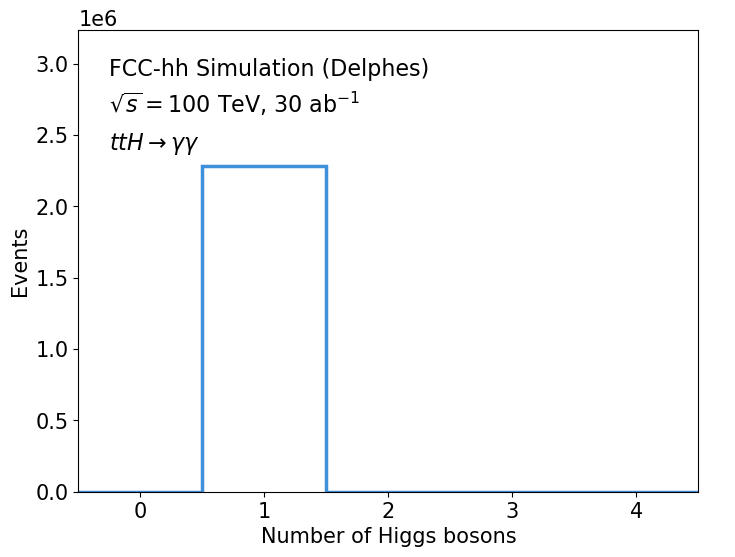

{'name': 'E_higgs', 'title': 'Higgs energy [GeV]', 'bin': 50, 'xmin': 0.0, 'xmax': 5000.0}


/tmp/elmazzeo/ipykernel_1129262/167052612.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 1.00))


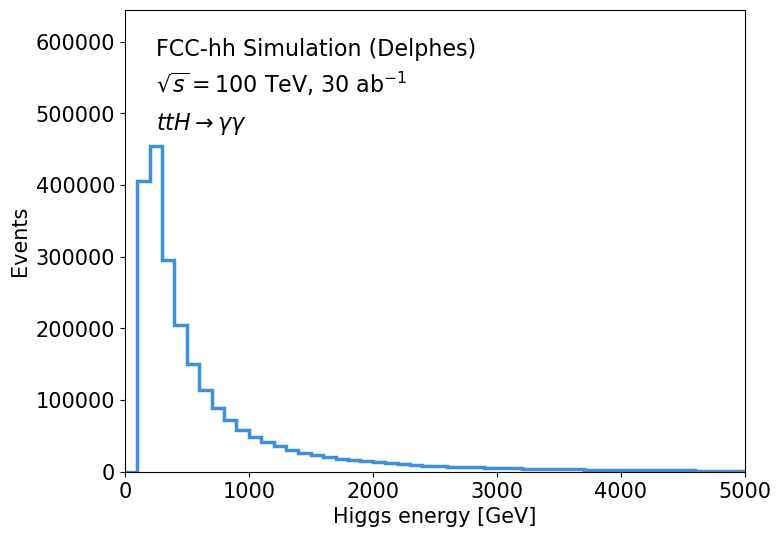

{'name': 'pT_higgs', 'title': 'Higgs p_{T} [GeV]', 'bin': 40, 'xmin': 0.0, 'xmax': 1000.0, 'latex': 'Higgs $p_{T}$ [GeV]'}


/tmp/elmazzeo/ipykernel_1129262/167052612.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 1.00))


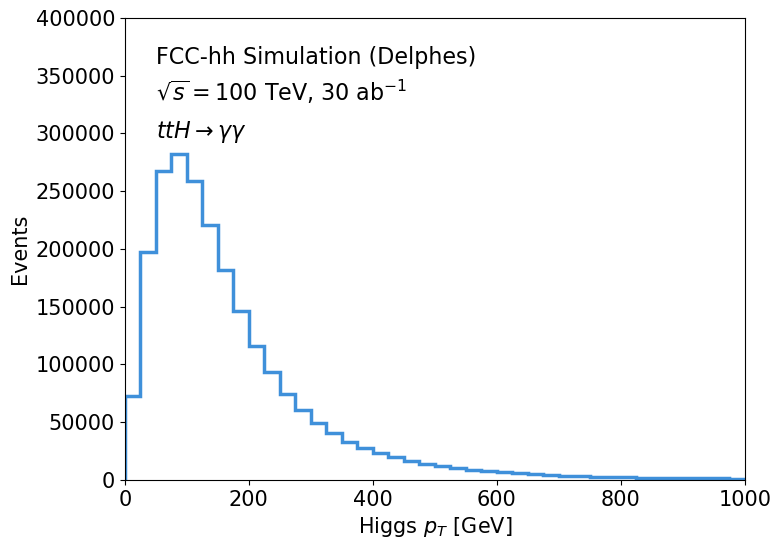

{'name': 'eta_higgs', 'title': 'Higgs #eta', 'bin': 40, 'xmin': -6.0, 'xmax': 6.0, 'latex': 'Higgs $\\eta$'}


/tmp/elmazzeo/ipykernel_1129262/167052612.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 1.00))


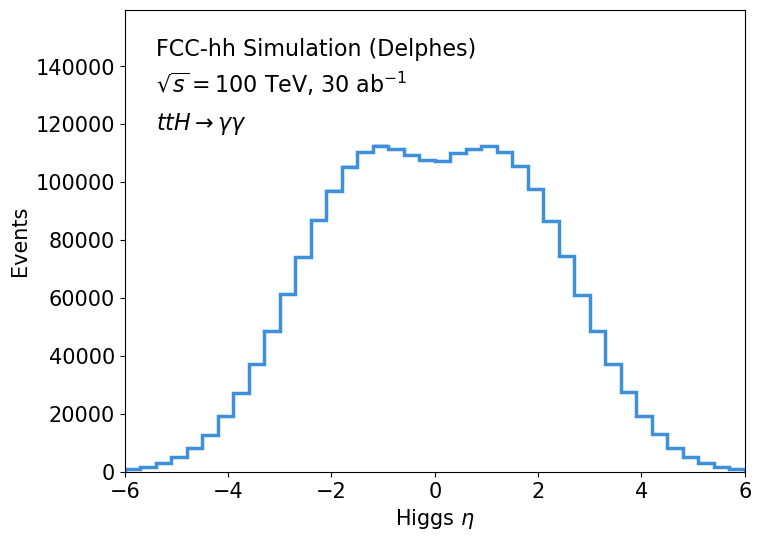

{'name': 'phi_higgs', 'title': 'Higgs #phi', 'bin': 50, 'xmin': -3.6, 'xmax': 3.6, 'latex': 'Higgs $\\phi$'}


/tmp/elmazzeo/ipykernel_1129262/167052612.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 1.00))


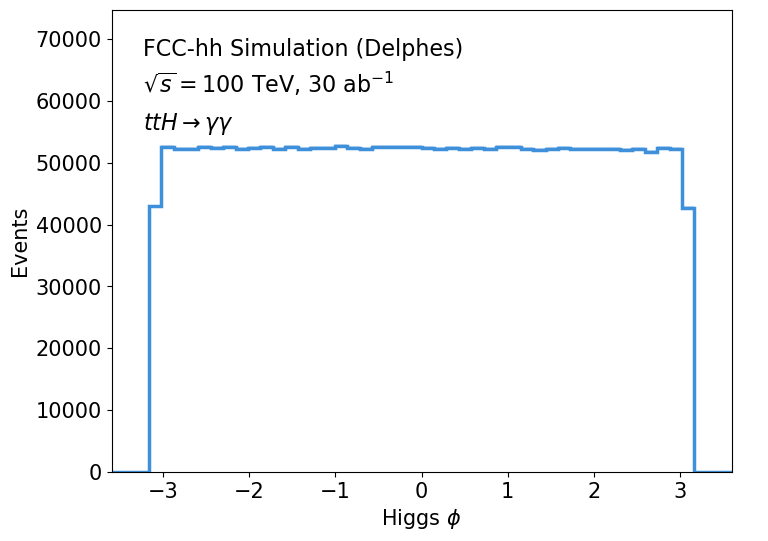

{'name': 'phi_higgs', 'title': 'Higgs rapidity', 'bin': 50, 'xmin': -10, 'xmax': 10, 'latex': 'Higgs rapidity'}


/tmp/elmazzeo/ipykernel_1129262/167052612.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 1.00))


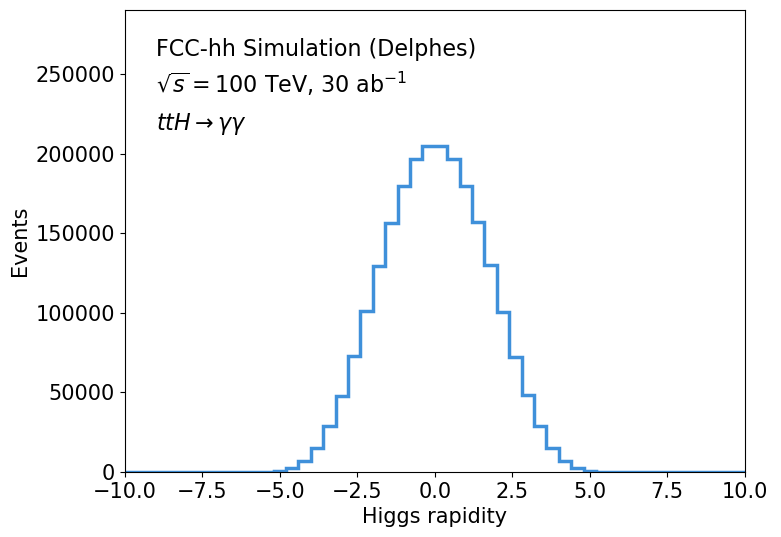

{'name': 'higgs_decay_type', 'title': 'Higgs decay type', 'bin': 11, 'xmin': -0.5, 'xmax': 11.0, 'latex': 'Higgs decay type'}


/tmp/elmazzeo/ipykernel_1129262/167052612.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 1.00))


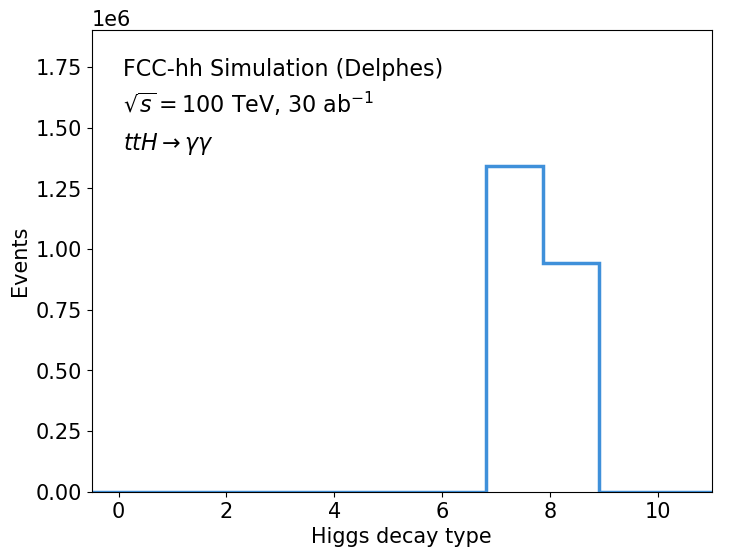

In [50]:
for v in ['n_higgs', 'E_higgs', 'pT_higgs', 'eta_higgs', 'phi_higgs', 'rapidity_higgs', 'higgs_decay_type'] :
    my_dict = for_plotting[v] if v in list(for_plotting.keys()) else variables_dict[v]
    fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=(8,6)
    )
    print(my_dict)
    # plot number of reco photons from Higgs using the Myy algorithm
    bin_values, bin_edges, _ = ax.hist(df1[v], weights=df1["weight"]*lumi,
            bins=my_dict['bin'], 
            range=(my_dict['xmin'], my_dict['xmax']),
            histtype='step', linewidth=2.5, color=color_sequence[0])

    # uncertainty
    x = 0.5*(bin_edges[1:]+bin_edges[:-1])
    xerr = 0.5*(bin_edges[1:]-bin_edges[:-1])
    bin_unc, _ = np.histogram(df1[v], weights=(df1["weight"]*lumi)*2, 
                              bins=my_dict['bin'], 
                              range=(my_dict['xmin'], my_dict['xmax']))
    bin_unc = np.sqrt(bin_unc)
    error_boxes(ax, x, bin_values, xerr, bin_unc, alpha=0.3, fc=color_sequence[0])
    
    ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
    ax.text(0.05, 0.82, r"$\sqrt{s}=100$ TeV, 30 ab$^{-1}$", transform=ax.transAxes, fontsize=16)
    ax.text(0.05, 0.74, process_label, transform=ax.transAxes, fontsize=16)

    ax.legend(loc='upper left', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 1.00))
    xlabel = my_dict['latex'] if 'latex' in list(my_dict.keys()) else my_dict['title']
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'Events')

    ax.set_xlim(my_dict['xmin'],my_dict['xmax'])
    ymin,ymax = ax.get_ylim() 
    ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.35)
    
    plotname = v+"_ttHyy_analysis_nocuts"
    plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
    plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
    plt.show()

In [53]:
df1['higgs_decay_type'].unique()

array([7, 8], dtype=int32)